In [5]:
import pandas as pd
import numpy as np

data = pd.read_excel("Adidas.xlsx", header=4)
print(data.head(5))

   Unnamed: 0     Retailer  Retailer ID Invoice Date     Region     State  \
0         NaN  Foot Locker      1185732   2020-01-01  Northeast  New York   
1         NaN  Foot Locker      1185732   2020-01-02  Northeast  New York   
2         NaN  Foot Locker      1185732   2020-01-03  Northeast  New York   
3         NaN  Foot Locker      1185732   2020-01-04  Northeast  New York   
4         NaN  Foot Locker      1185732   2020-01-05  Northeast  New York   

       City                    Product  Price per Unit  Units Sold  \
0  New York      Men's Street Footwear            50.0        1200   
1  New York    Men's Athletic Footwear            50.0        1000   
2  New York    Women's Street Footwear            40.0        1000   
3  New York  Women's Athletic Footwear            45.0         850   
4  New York              Men's Apparel            60.0         900   

   Total Sales  Operating Profit  Operating Margin Sales Method  
0     600000.0          300000.0              0.50

In [6]:
# Remove Date column (not useful for classification directly)
data = data.drop(columns=['Invoice Date'])

In [7]:
# Fill missing numeric values with mean
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

In [8]:
# Fill missing categorical values with most frequent value
categorical_cols = data.select_dtypes(include='object').columns
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

In [9]:
# Features (X) and target (y)
y = data['Sales Method']
X = data.drop(columns=['Sales Method'])

In [10]:
# Convert categorical features into numeric
X = pd.get_dummies(X, drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Prediction
y_pred = model.predict(X_test)
print(y_pred)

['In-store' 'Online' 'Online' ... 'Online' 'Online' 'In-store']


In [14]:
from sklearn.metrics import accuracy_score

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.2f}')

Accuracy Score: 0.94


In [15]:
from sklearn.metrics import classification_report

print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

    In-store       0.98      0.96      0.97       370
      Online       0.95      0.96      0.95       980
      Outlet       0.91      0.91      0.91       580

    accuracy                           0.94      1930
   macro avg       0.95      0.94      0.94      1930
weighted avg       0.94      0.94      0.94      1930



In [16]:
from sklearn.metrics import confusion_matrix

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[355   3  12]
 [  3 940  37]
 [  6  47 527]]


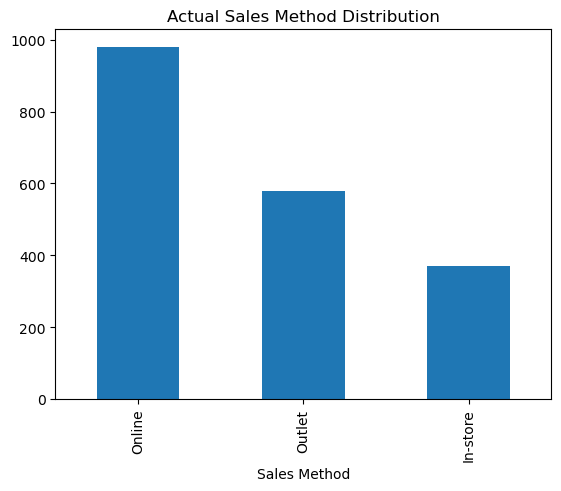

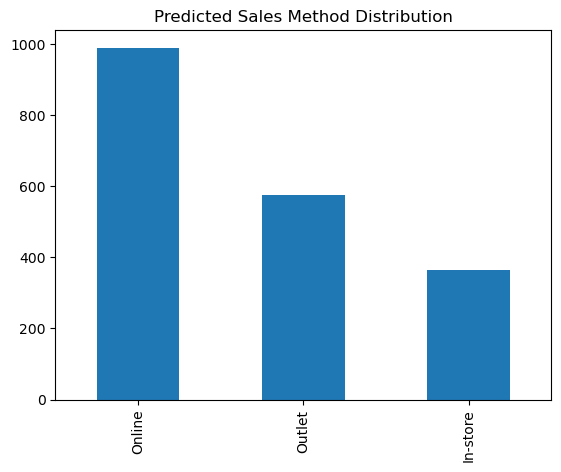

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(y_test).value_counts().plot(kind='bar')
plt.title("Actual Sales Method Distribution")
plt.show()

pd.Series(y_pred).value_counts().plot(kind='bar')
plt.title("Predicted Sales Method Distribution")
plt.show()

In [17]:
import pandas as pd
import numpy as np

data = pd.read_excel("Adidas.xlsx", header=4)

data = data.drop(columns=['Invoice Date'])

numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

categorical_cols = data.select_dtypes(include='object').columns
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

y = data['Sales Method']
X = data.drop(columns=['Sales Method'])

X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
import joblib

joblib.dump(model, "adidas_rf_model.pkl")
joblib.dump(X.columns, "model_features.pkl")

['model_features.pkl']

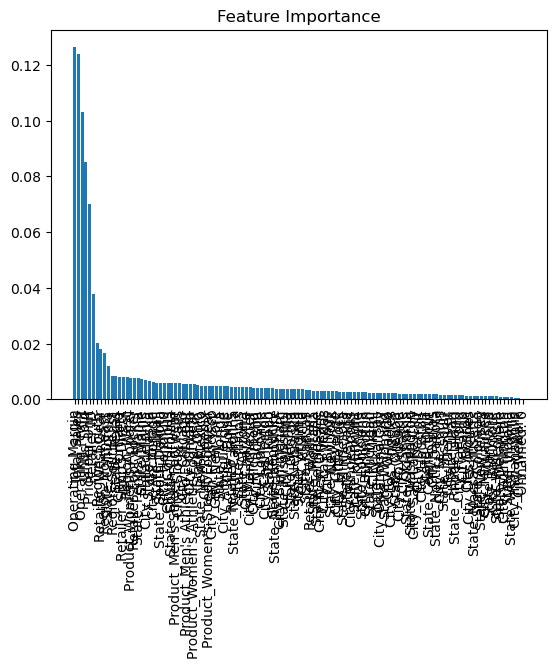

In [19]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

# Sort features by importance
indices = importance.argsort()[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), feature_names[indices], rotation=90)
plt.show()

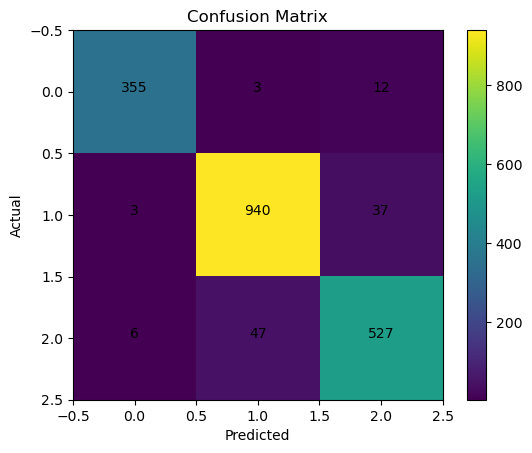

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center")

plt.show()